# C-SON — Surface KE around Africa (regional grids vs. coarse background)

Surface kinetic energy `ke = 0.5 (u**2 + v**2)` from GLORYS, rendered with a
Line Integral Convolution (LIC) of the surface currents:

- **Inside** the African regional grids: full-resolution LIC (eddies + jets).
- **Outside**: KE **block-averaged on a 20x20 box** of the GLORYS grid.

Grayscale Natural Earth relief land; thin black grid outlines; transparent
background. The GLORYS download happens **in-notebook over a configurable date
range**, so the same machinery makes a still (`cson-map-ke-africa.png`) and an
animation (`cson-map-ke-africa.mp4`).


In [ ]:
import os, glob, zipfile, urllib.request, warnings, shutil
import numpy as np
import numba
import yaml
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from matplotlib.path import Path
from matplotlib.animation import FFMpegWriter
import cartopy
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds
import roms_tools as rt

CACHE = os.path.expanduser("~/Library/Caches/roms-tools")
if shutil.which("ffmpeg"):
    plt.rcParams["animation.ffmpeg_path"] = shutil.which("ffmpeg")

# --- View / field configuration ---
CENTER_LON, CENTER_LAT = 20.0, 10.0
BOX = dict(lon=(-85, 115), lat=(-80, 85))   # hemisphere velocity box (covers Arabian Sea)
BLOCK = 20                                   # 20x20 block average outside the grids
KE_PCT, KE_GAMMA = 99.5, 0.42

# --- Time configuration ---
MOVIE_START = "2019-01-01"     # date range to download + animate (daily GLORYS)
MOVIE_END   = "2019-12-31"
STILL_DATE  = "2019-01-01"     # frame used for the still PNG + the fixed colour scale
FPS = 12

# --- LIC + shade ---
LIC_STEPS, LIC_STEP = 32, 0.5
LIC_CONTRAST = 2.2
SHADE_FLOOR, SHADE_GAIN = 0.45, 1.0
REGRID_OCEAN, REGRID_LAND = 2200, 2200

# Regional model grids around Africa
AFRICAN_REGIONALS = {
    "benguela_current", "canary_current", "gulf_of_guinea", "east_africa",
    "south_africa", "mediterranean", "arabian_sea",
}

OCEAN_CMAP = LinearSegmentedColormap.from_list(
    "perpetual",
    ["#0c2150", "#143a7d", "#1f6fbf", "#56a8e0", "#bfe4f7", "#ffffff"],
)

# Geometry-only grid build (skip slow topography / vertical steps)
rt.Grid.update_topography = lambda self, *a, **k: None
rt.Grid.update_vertical_coordinate = lambda self, *a, **k: None


def grid_perimeter(g):
    """Closed (lon, lat) boundary of a roms_tools grid, lon in [-180, 180)."""
    lo = g.ds.lon_rho.values
    la = g.ds.lat_rho.values
    el = np.concatenate([lo[0, :], lo[1:, -1], lo[-1, -2::-1], lo[-2:0:-1, 0], lo[0:1, 0]])
    ea = np.concatenate([la[0, :], la[1:, -1], la[-1, -2::-1], la[-2:0:-1, 0], la[0:1, 0]])
    return ((el + 180) % 360 - 180), ea


@numba.njit(parallel=True)
def line_integral_convolution(u, v, noise, n_steps, step_len):
    """LIC: smear a noise texture along the streamlines of (u, v)."""
    ny, nx = u.shape
    out = np.zeros((ny, nx))
    for j in numba.prange(ny):
        for i in range(nx):
            acc = noise[j, i]
            wsum = 1.0
            for d in (1.0, -1.0):
                x = i + 0.5
                y = j + 0.5
                for _ in range(n_steps):
                    ix, iy = int(x), int(y)
                    if ix < 0 or ix >= nx or iy < 0 or iy >= ny:
                        break
                    fx, fy = u[iy, ix], v[iy, ix]
                    sp = (fx * fx + fy * fy) ** 0.5
                    if sp < 1e-9:
                        break
                    x += d * fx / sp * step_len
                    y += d * fy / sp * step_len
                    ix, iy = int(x), int(y)
                    if ix < 0 or ix >= nx or iy < 0 or iy >= ny:
                        break
                    acc += noise[iy, ix]
                    wsum += 1.0
            out[j, i] = acc / wsum
    return out


In [2]:
# --- In-notebook GLORYS download (date range -> one file with a time axis) ---
def download_glorys(start, end, box):
    """Download daily GLORYS surface uo/vo for [start, end]; cache + return ds."""
    fn = f"GLORYS_uovo_hemi_{start}_{end}.nc"
    path = os.path.join(CACHE, fn)
    if not os.path.exists(path):
        import copernicusmarine as cm
        cm.subset(
            dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
            variables=["uo", "vo"],
            minimum_longitude=box["lon"][0], maximum_longitude=box["lon"][1],
            minimum_latitude=box["lat"][0], maximum_latitude=box["lat"][1],
            minimum_depth=0, maximum_depth=1,
            start_datetime=f"{start}T00:00:00", end_datetime=f"{end}T00:00:00",
            output_directory=CACHE, output_filename=fn, overwrite=True,
        )
    return xr.open_dataset(path)

ds = download_glorys(MOVIE_START, MOVIE_END, BOX).squeeze("depth", drop=True)
print("times:", ds.sizes.get("time", 1), "| grid:", ds.sizes["latitude"], "x", ds.sizes["longitude"])

# Gray Earth shaded-relief raster
GRAY_DIR = os.path.join(CACHE, "GRAY_50M_SR_OB")
_hits = glob.glob(os.path.join(GRAY_DIR, "**", "GRAY_50M_SR_OB.tif"), recursive=True)
if not _hits:
    _zp = os.path.join(CACHE, "GRAY_50M_SR_OB.zip")
    urllib.request.urlretrieve(
        "https://naturalearth.s3.amazonaws.com/50m_raster/GRAY_50M_SR_OB.zip", _zp)
    with zipfile.ZipFile(_zp) as z:
        z.extractall(GRAY_DIR)
    os.remove(_zp)
    _hits = glob.glob(os.path.join(GRAY_DIR, "**", "GRAY_50M_SR_OB.tif"), recursive=True)
GRAY_PATH = _hits[0]
print("gray earth:", os.path.basename(GRAY_PATH))


INFO - 2026-06-11T03:40:20Z - Selected dataset version: "202311"


2026-06-11 03:40:20 - INFO - Selected dataset version: "202311"


INFO - 2026-06-11T03:40:20Z - Selected dataset part: "default"


2026-06-11 03:40:20 - INFO - Selected dataset part: "default"


WARNING - 2026-06-11T03:40:20Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


...

2026-06-11 03:40:35 - WARNING - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10


2026-06-11 03:40:35 - WARNING - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10


2026-06-11 03:40:35 - WARNING - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10


2026-06-11 03:40:35 - WARNING - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10


times: 20 | grid: 1981 x 2401
gray earth: GRAY_50M_SR_OB.tif


In [3]:
# --- Static pieces shared by every frame ---
olon = ds["longitude"].values
olat = ds["latitude"].values                      # ascending -> origin="lower"
ocean_extent = [olon.min(), olon.max(), olat.min(), olat.max()]

# Regional grid footprints (geometry only) + in-grid mask on the GLORYS grid
cfg = yaml.safe_load(open("grids.yml"))["grids"]
grids = {}
for name, info in cfg.items():
    if name in AFRICAN_REGIONALS:
        kw = dict(info["grid_kwargs"]); kw.pop("topography_source", None)
        grids[name] = rt.Grid(**kw)
perimeters = {n: grid_perimeter(g) for n, g in grids.items()}
print("regional grids:", list(grids))

ny, nx = ds["uo"].isel(time=0).shape
inside = np.zeros((ny, nx), bool)
for el, ea in perimeters.values():
    ii = np.where((olon >= el.min()) & (olon <= el.max()))[0]
    jj = np.where((olat >= ea.min()) & (olat <= ea.max()))[0]
    LON, LAT = np.meshgrid(olon[ii], olat[jj])
    m = Path(np.column_stack([el, ea])).contains_points(
        np.column_stack([LON.ravel(), LAT.ravel()])).reshape(LON.shape)
    inside[np.ix_(jj, ii)] |= m

# Static masks / trim dims / noise (fixed seed -> temporally coherent texture)
NY2, NX2 = (ny // BLOCK) * BLOCK, (nx // BLOCK) * BLOCK
u0_first = ds["uo"].isel(time=0).values
SEA = np.isfinite(u0_first)
SEA_T = SEA[:NY2, :NX2]
INSIDE_T = inside[:NY2, :NX2]
NOISE = np.random.default_rng(0).random((ny, nx))

# Fixed colour scale (from the still date) so the movie does not flicker
ti_still = int(np.argmin(np.abs(ds["time"].values - np.datetime64(STILL_DATE))))
_u = ds["uo"].isel(time=ti_still).values
_v = ds["vo"].isel(time=ti_still).values
_ke = 0.5 * (_u ** 2 + _v ** 2)
KE_VMAX = float(np.nanpercentile(_ke[SEA], KE_PCT))
NORM = PowerNorm(KE_GAMMA, vmin=0, vmax=KE_VMAX)
print("still index:", ti_still, "| KE vmax:", round(KE_VMAX, 3))


regional grids: ['benguela_current', 'canary_current', 'gulf_of_guinea', 'east_africa', 'south_africa', 'arabian_sea', 'mediterranean']


still index: 14 | KE vmax: 0.475


In [4]:
# --- Grayscale Natural Earth relief land, masked to land (static) ---
COARSEN = 2
g = rioxarray.open_rasterio(GRAY_PATH).isel(band=0).values.astype("float32")
ly, lx = g.shape
ly2, lx2 = ly // COARSEN, lx // COARSEN
g = g[:ly2 * COARSEN, :lx2 * COARSEN].reshape(ly2, COARSEN, lx2, COARSEN).mean(axis=(1, 3))
ly, lx = ly2, lx2
geoms = list(shpreader.Reader(shpreader.natural_earth(
    resolution="50m", category="physical", name="land")).geometries())
land_mask = geometry_mask(geoms, out_shape=(ly, lx),
                          transform=from_bounds(-180, -90, 180, 90, lx, ly), invert=True)
lo, hi = g[land_mask].min(), g[land_mask].max()
gs = np.clip((g - lo) / (hi - lo), 0, 1)
LAND_RGBA = np.dstack([np.repeat(gs[..., None], 3, axis=-1), land_mask.astype(float)])
print("land RGBA:", LAND_RGBA.shape)


land RGBA: (2700, 5400, 4)


In [5]:
# --- Per-frame KE -> RGBA, and the globe drawing routine ---
def ocean_rgba(u, v):
    """LIC full-res inside grids, 20x20 block-average outside; -> RGBA image."""
    ke = 0.5 * (u ** 2 + v ** 2)
    u0 = np.where(SEA, u, 0.0); v0 = np.where(SEA, v, 0.0)
    lic = line_integral_convolution(u0, v0, NOISE, LIC_STEPS, LIC_STEP)
    ms, sd = lic[SEA].mean(), lic[SEA].std()
    shade = np.clip((lic - ms) / (LIC_CONTRAST * sd) + 0.5, 0, 1)
    base = OCEAN_CMAP(NORM(np.where(SEA, ke, 0)))[..., :3]
    perp = np.clip(base * (SHADE_FLOOR + SHADE_GAIN * shade)[..., None], 0, 1)

    kf = ke[:NY2, :NX2]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        coarse = np.nanmean(kf.reshape(NY2 // BLOCK, BLOCK, NX2 // BLOCK, BLOCK), axis=(1, 3))
    blocky = np.repeat(np.repeat(coarse, BLOCK, axis=0), BLOCK, axis=1)
    blocky_rgb = np.clip(OCEAN_CMAP(NORM(np.where(SEA_T, blocky, 0)))[..., :3]
                         * (SHADE_FLOOR + SHADE_GAIN * 0.5), 0, 1)

    comp = np.where(INSIDE_T[..., None], perp[:NY2, :NX2], blocky_rgb)
    return np.dstack([comp, SEA_T.astype(float)])


PRJ = ccrs.Orthographic(central_longitude=CENTER_LON, central_latitude=CENTER_LAT)

def add_static_layers(ax):
    ax.add_feature(cartopy.feature.OCEAN, facecolor="#0c2150", zorder=-10)
    ax.imshow(LAND_RGBA, extent=[-180, 180, -90, 90], origin="upper",
              transform=ccrs.PlateCarree(), zorder=10, regrid_shape=REGRID_LAND)
    for el, ea in perimeters.values():
        ax.plot(el, ea, color="black", linewidth=0.8, transform=ccrs.PlateCarree(), zorder=12)
    ax.set_global()
    ax.spines["geo"].set_visible(False)

def add_ocean(ax, rgba):
    return ax.imshow(rgba, extent=ocean_extent, origin="lower", transform=ccrs.PlateCarree(),
                     zorder=0, interpolation="nearest", regrid_shape=REGRID_OCEAN)


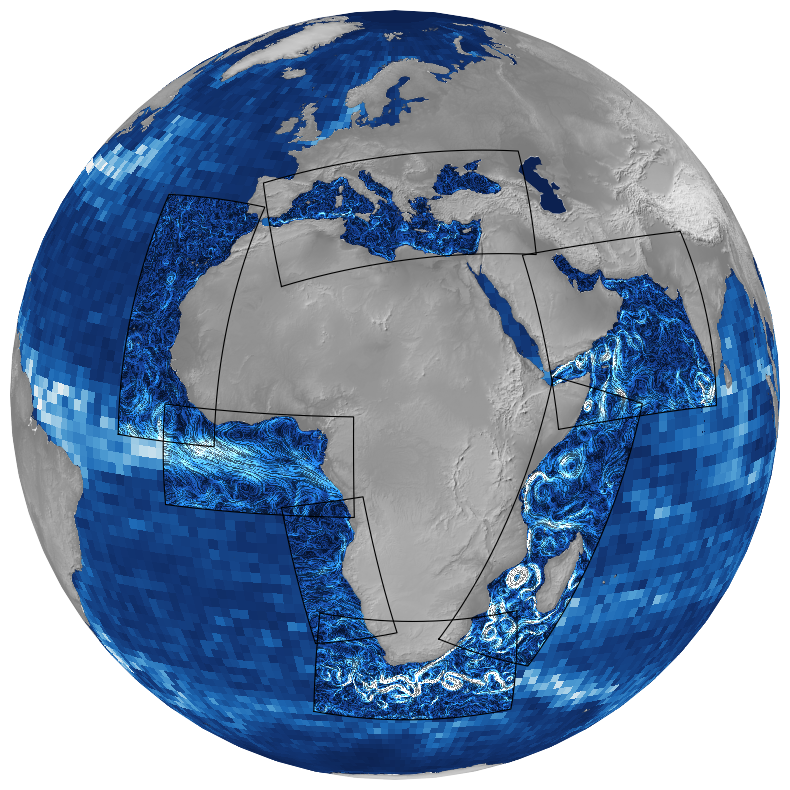

In [6]:
# --- Still figure (transparent background) ---
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection=PRJ))
fig.patch.set_facecolor("none")
add_static_layers(ax)
add_ocean(ax, ocean_rgba(ds["uo"].isel(time=ti_still).values,
                         ds["vo"].isel(time=ti_still).values))
fig.savefig("cson-map-ke-africa.png", dpi=200, bbox_inches="tight", transparent=True)
plt.show()


In [7]:
# --- Animation over the downloaded date range (mp4) ---
times = ds["time"].values
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection=PRJ))
fig.patch.set_facecolor("white")          # mp4 has no alpha; render on white
add_static_layers(ax)                      # land + grids warped once

writer = FFMpegWriter(fps=FPS, metadata={"title": "C-SON surface KE around Africa"})
ocean_im = None
label = None
with writer.saving(fig, "cson-map-ke-africa.mp4", dpi=120):
    for t in range(len(times)):
        if ocean_im is not None:
            ocean_im.remove()
        ocean_im = add_ocean(ax, ocean_rgba(ds["uo"].isel(time=t).values,
                                            ds["vo"].isel(time=t).values))
        if label is not None:
            label.remove()
        label = ax.text(0.5, 0.04, str(times[t])[:10], transform=ax.transAxes,
                        ha="center", va="center", fontsize=14, color="0.2")
        writer.grab_frame()
plt.close(fig)
print("wrote cson-map-ke-africa.mp4 (", len(times), "frames )")


2026-06-11 03:41:01 - INFO - MovieWriter._run: running command: /opt/homebrew/bin/ffmpeg -f rawvideo -vcodec rawvideo -s 1200x1200 -pix_fmt rgba -framerate 6 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -metadata 'title=C-SON surface KE around Africa' -y cson-map-ke-africa.mp4


wrote cson-map-ke-africa.mp4 ( 20 frames )
